In [1]:
# Add module to path
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from itertools import product
from numba import jit, njit, types
from numba.typed import Dict
import time

from darts.dartboards import generate_dartboard
from darts.stats import expected_score, std_score, gaussian_filter

In [3]:
board_size = 128

In [4]:
board, checkouts = generate_dartboard(board_size)

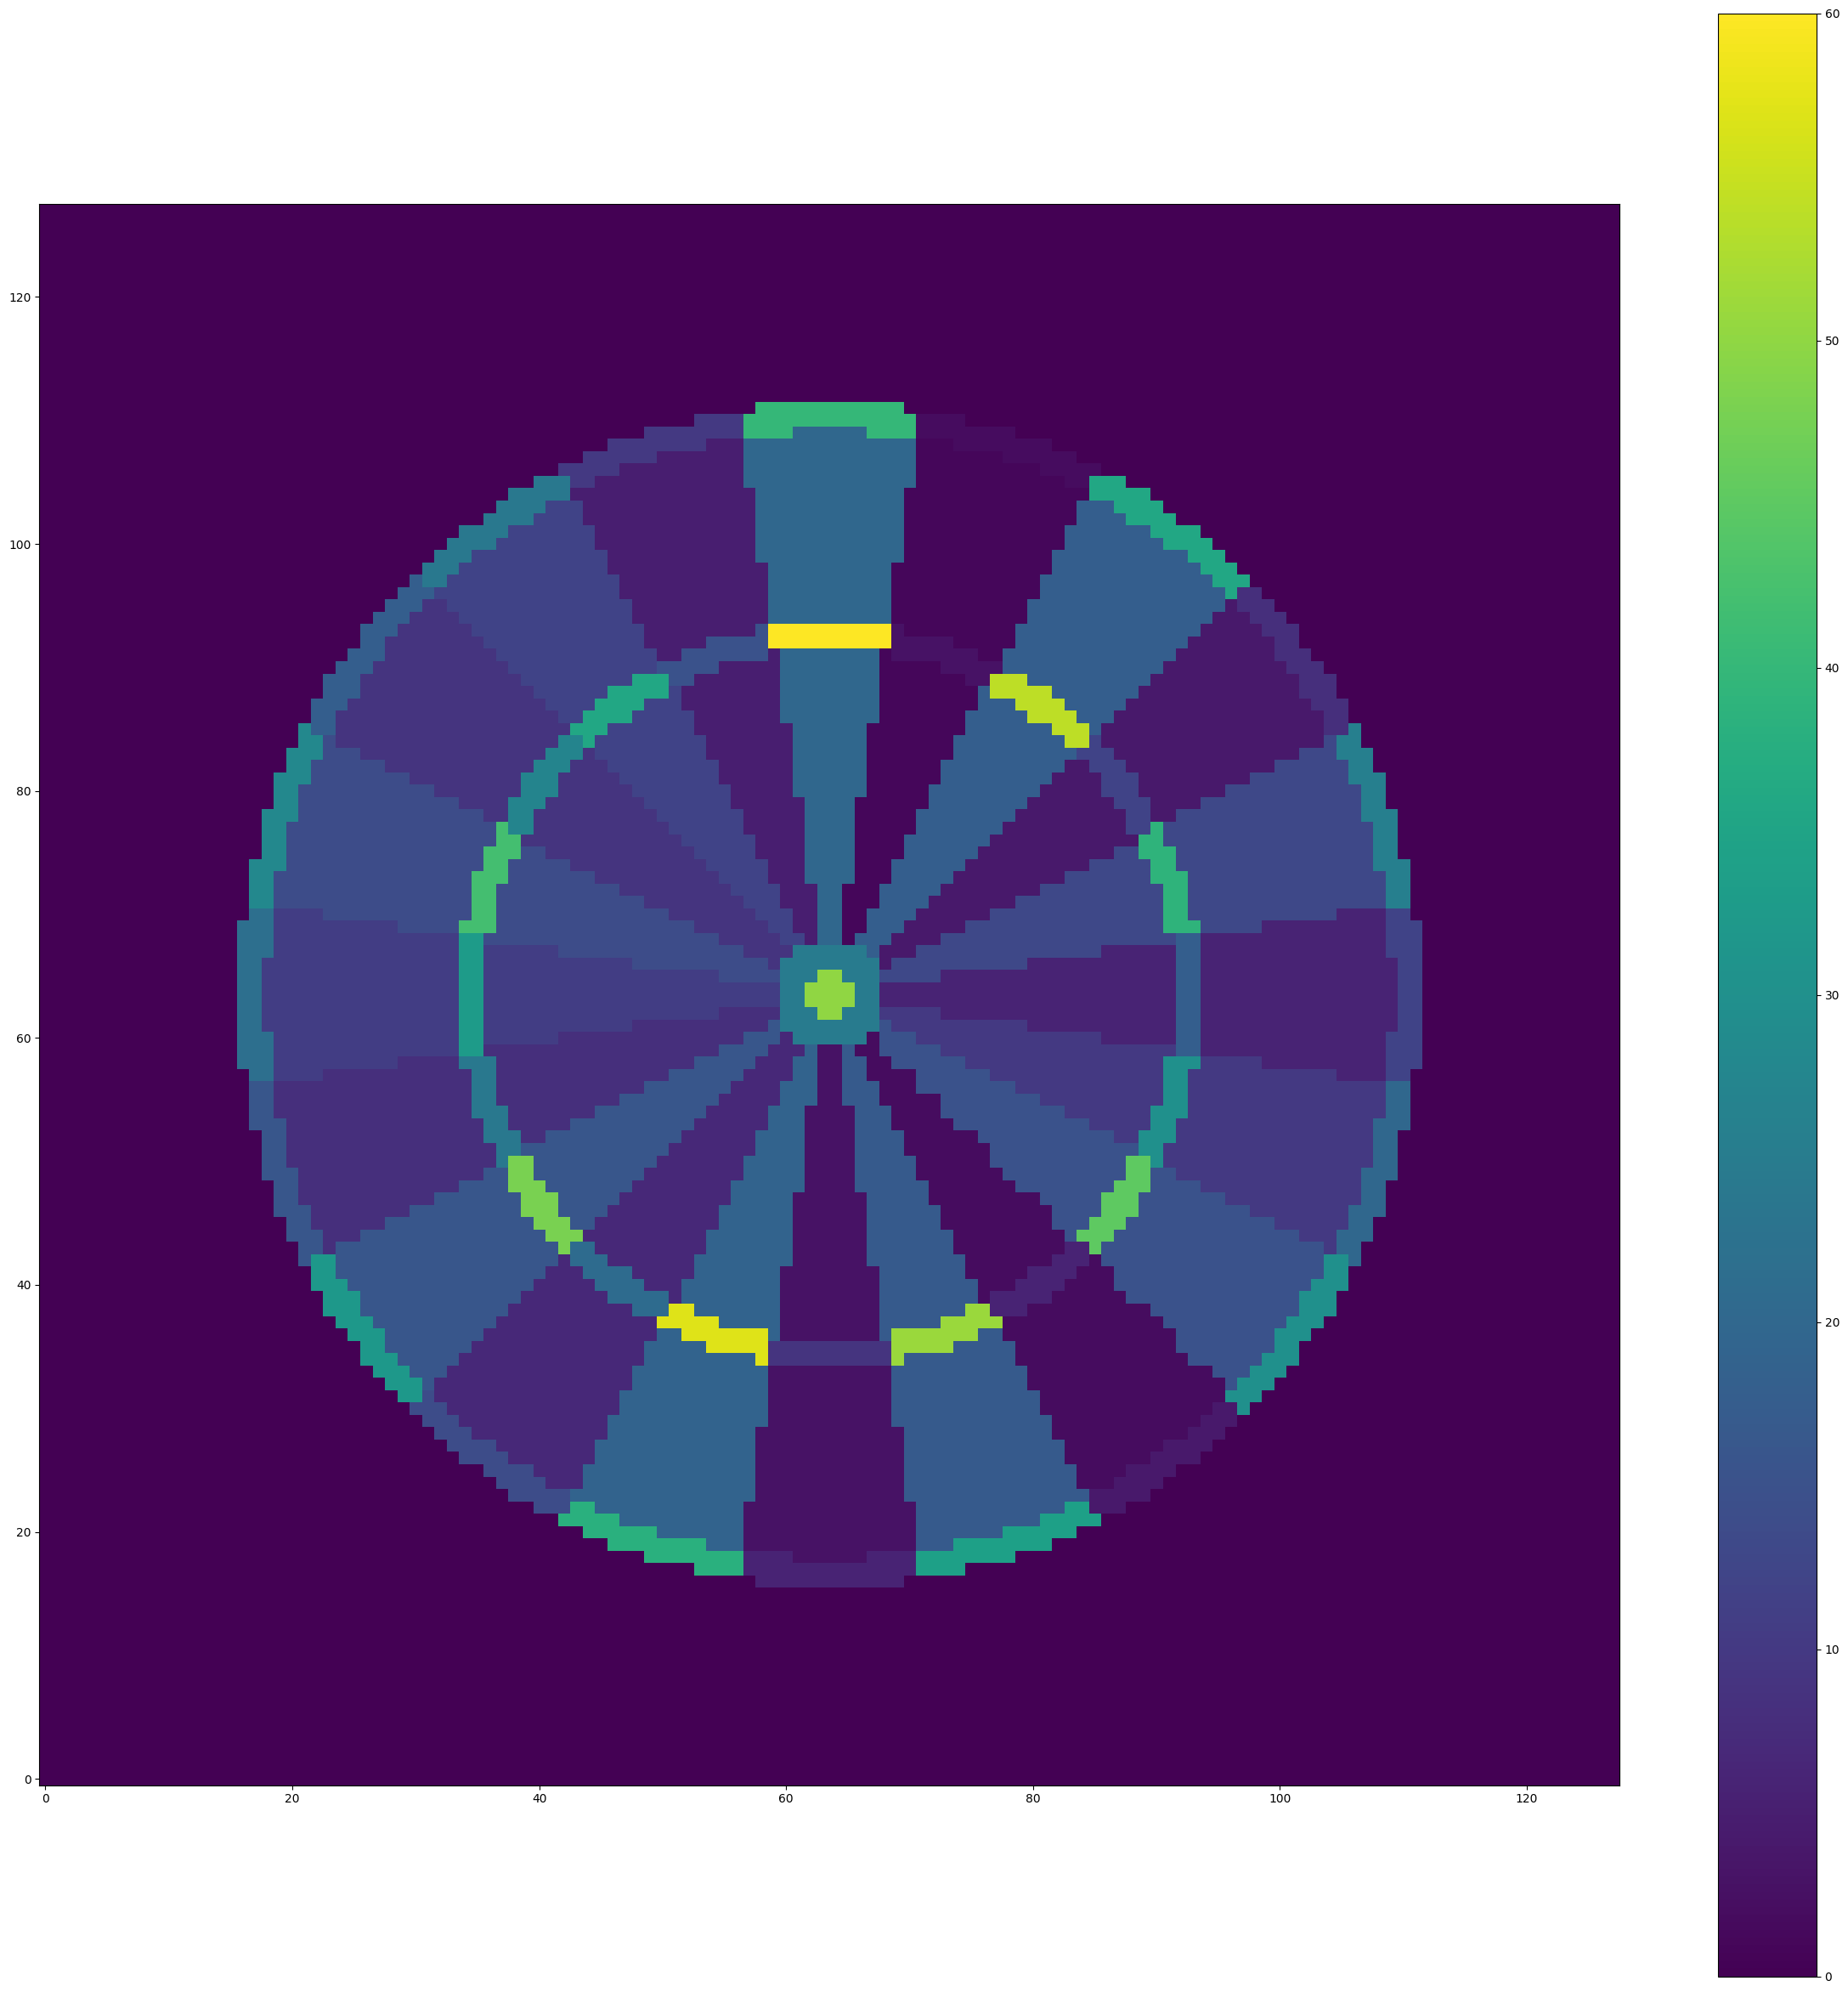

In [5]:
fig, ax = plt.subplots(figsize=(30, 30))
plt.imshow(board, origin='lower')
plt.colorbar()

In [6]:
sigma = 8

In [7]:
mu = np.array([0, 0])
Sigma = sigma*sigma*np.array([[1, 0], [0, 1]])

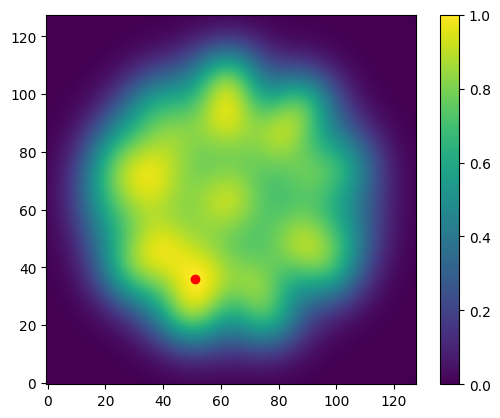

In [8]:
exp = expected_score(board, mu, Sigma, padding=100)
i, j = np.unravel_index(np.argmax(exp), board.shape)
plt.imshow(exp, origin='lower')
plt.scatter(j, i, color='red')
plt.colorbar()

#### States

State $S$ is defined by:
- Current score $s$
- Current throw $t$
- Starting score $u$

Remove some points that are too far from the dartboard

In [9]:
radius_pixels = int(170/225.5*board_size/2)
margin = 2*sigma

In [10]:
centre = np.array([int(board_size/2), int(board_size/2)])
ratio = 1 # board_size//200
points = [(ratio*i, ratio*j) for i, j in product(range(board_size//ratio), range(board_size//ratio))
          if np.linalg.norm(np.array([ratio*i, ratio*j]) - centre) < radius_pixels + margin]

In [11]:
len(points)

12849

In [12]:
len(points)/board_size**2

0.78424072265625

Let's start by initializing values to 0:

In [13]:
game_start = 501

In [14]:
nonzero_values = {(0, turn, start): 1 for turn, start in product([0, 1, 2], range(game_start+1))}
zero_values = {
    (score, turn, start): 0 for score, turn, start in product(range(1, game_start+1), [0, 1, 2], range(1, game_start+1))
}

In [15]:
values = {**zero_values, **nonzero_values}

In [16]:
## Simplified
values = {score: 0 for score in range(game_start+1)}

In [17]:
len(values)

502

In [18]:
len(points)

12849

### Transition probabilities

Compute transition probabilities
Probability defined by:
- initial state
- final state
- point aimed at

In [19]:
%load_ext line_profiler

In [20]:
allowed_scores = np.array([0, 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
        16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 30, 32, 33, 34,
        36, 38, 39, 40, 42, 45, 48, 50, 51, 54, 57, 60])

In [21]:
def shift_array(array, shift):
    ret = np.empty_like(filt)
    ret[shift[0]: , shift[1]:] = filt[:-shift[0], :-shift[1]]
    return ret

In [22]:
@njit
def prob_score(filt, board, allowed_scores, checkouts):
    probs = {int(s): 0.0 for s in allowed_scores}
    checkout_probs = {int(s): 0.0 for s in allowed_scores}
    for i in range(filt.shape[0]):
        for j in range(filt.shape[1]):
            probs[int(board[i, j])] += filt[i, j]
            
            if checkouts[i, j]:
                checkout_probs[int(board[i, j])] += filt[i, j]
                
    return probs, checkout_probs

In [23]:
def transition_probs(start, board, allowed_scores, checkouts, Sigma):
    gf = gaussian_filter(board, (start[0], start[1]), Sigma)
    gf = gf / np.sum(gf)
    return prob_score(gf, board, allowed_scores, checkouts)

In [24]:
# %timeit transition_probs((0, 0), board, allowed_scores, Sigma)

In [25]:
# %lprun -f transition_probs transition_probs((0, 0), board, allowed_scores, Sigma)

In [26]:
probs = {}
checkout_probs = {}
for start in tqdm(points):
    probs[start], checkout_probs[start] = transition_probs(start - centre, 
                                                           board, 
                                                           allowed_scores,
                                                           checkouts,
                                                           Sigma)

  0%|                                                                                        | 0/12849 [00:00<?, ?it/s]C:\Users\mikey\AppData\Local\Temp\ipykernel_26656\3425330339.py:7: NumbaTypeSafetyWarning: unsafe cast from int64 to int32. Precision may be lost.
  probs[int(board[i, j])] += filt[i, j]
100%|███████████████████████████████████████████████████████████████████████████| 12849/12849 [00:17<00:00, 747.70it/s]


128: 16 seconds

256: 4min 3seconds

In [27]:
probs[(64, 64)][50]

0.029876338479949416

In [28]:
checkout_probs[(64, 64)][50]

0.029876338479949416

In [29]:
len(points)

12849

In [30]:
@njit
def _compute_values_iteration(values, points, probs, checkout_probs):
    delta = 0
    for state in values:
        if state == 0 or state == 1:
            continue
        max_q = -np.inf

        for point in points:
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                # Found the problem - point is the aim point, not the scoring point
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1)

            if q >= max_q:
                max_q = q
        delta = max(delta, np.abs(max_q - values[state]))
        values[state] = max_q
    return delta, values

def compute_values(values, points, probs, checkout_probs, threshold):
    # Setup for numba function
    new_d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
    for k, v in values.items():
        new_d_values[k] = v
        
    d_probs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in probs.items():
        d_probs[','.join([str(x) for x in k])] = v
        
    d_cprobs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in checkout_probs.items():
        d_cprobs[','.join([str(x) for x in k])] = v
        
    deltas = []
    delta = np.inf
    while delta > threshold:
        d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
        for k, v in new_d_values.items():
            d_values[k] = v
        delta, new_d_values = _compute_values_iteration(d_values, np.array(points), d_probs, d_cprobs)
        deltas.append(delta)
        print(delta)
        
    return deltas, new_d_values

In [31]:
# Reinitialize values
values = {k: -12-k/12 for k in values.keys()}
values[0] = 0
values[1] = 0

In [32]:
start = time.time()
deltas, values = compute_values(values, points, probs, checkout_probs, 0.05)
end = time.time()

6.9716508880974
0.9822374080028311
0.4173890093741335
0.28246843946017464
0.234234937933385
0.19943911310001106
0.16789692756562147
0.1409292652223808
0.11859547577673446
0.10041389769534526
0.08572845767968573
0.07388357476736473
0.0642979745815051
0.05648732530529266
0.05006266757040301
0.044718814240347626


In [37]:
print((end - start) // 60, (end - start) % 60)

5.0 1.228053331375122


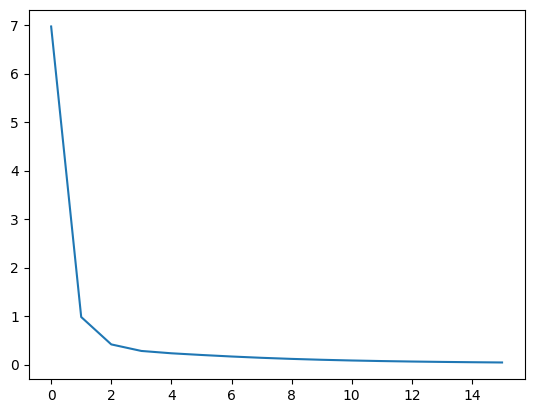

In [38]:
plt.plot(deltas)

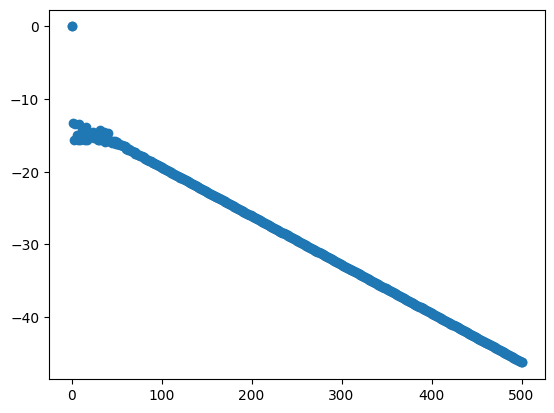

In [39]:
plt.scatter(values.keys(), values.values())

In [40]:
list(values.values())

[0.0,
 0.0,
 -13.284698712744763,
 -15.633620002786659,
 -13.374100325494956,
 -15.545492701681766,
 -14.89641688928523,
 -15.595178260738344,
 -13.467296809067362,
 -15.589388575097509,
 -15.03910523975296,
 -15.514996818459057,
 -14.151872922436855,
 -15.47253428246634,
 -14.839876795368168,
 -15.617470291232788,
 -13.847581667162489,
 -15.633051958657827,
 -14.692002548055669,
 -15.088715931579449,
 -14.759972473058921,
 -15.161778622873081,
 -14.627658057204115,
 -15.007516754328293,
 -14.525759970600676,
 -15.297135437289938,
 -14.88751382954903,
 -15.264377772854035,
 -14.803347900433081,
 -15.69373857411119,
 -14.944253091767655,
 -15.590009710188523,
 -14.20757289486761,
 -15.660158386002973,
 -15.030291102773557,
 -15.337274301166715,
 -14.506256704879737,
 -15.899409905961098,
 -14.908019533204737,
 -15.654033970105903,
 -14.699675405686143,
 -15.837227297215083,
 -15.596917142172428,
 -15.710340199603754,
 -15.861066366823872,
 -16.045461098027598,
 -15.827558258677833,
 -16

In [75]:
@njit
def _compute_policy(values, points, probs, checkout_probs):
    policy = Dict.empty(key_type=types.int32, value_type=types.int32[:])
    
    for state in values:
        if state == 0 or state == 1:
            continue
        max_q = -np.inf
        max_a = None

        for point in points:   
            key = f'{point[0]},{point[1]}'
            p = probs[key]
            cp = checkout_probs[key]
            q = 0
            
            for score in p:
                
                # Valid throw
                if score <= state-2:
                    q += p[score]*(values[state-score] - 1)

                # Checkout
                # Found the problem - point is the aim point, not the scoring point
                elif score == state:
                    q += cp[score]*(values[0] - 1)
                    q += (p[score] - cp[score])*(values[state] - 1)

                # Bust
                else:
                    q += p[score]*(values[state] - 1)
                    
            if q >= max_q:
                max_q = q
                max_a = point
                
        policy[state] = max_a
    return policy

def compute_policy(values, points, probs, checkout_probs):
    d_values = Dict.empty(key_type=types.int32, value_type=types.float64)
    for k, v in values.items():
        d_values[k] = v
        
    d_probs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in probs.items():
        d_probs[','.join([str(x) for x in k])] = v
        
    d_cprobs = Dict.empty(key_type=types.string, value_type=types.DictType(types.int32, types.float64))
    for k, v in checkout_probs.items():
        d_cprobs[','.join([str(x) for x in k])] = v
    
    if not isinstance(points, np.ndarray):
        points = np.array(points)
        
    return _compute_policy(d_values, points, d_probs, d_cprobs)

In [76]:
policy = compute_policy(values, points, probs, checkout_probs)

C:\Users\mikey\AppData\Local\Temp\ipykernel_10848\2510322301.py:37: NumbaTypeSafetyWarning: unsafe cast from none to array(int32, 1d, A). Precision may be lost.
  policy[state] = max_a


In [77]:
import pandas as pd
df = pd.DataFrame([(state, board[*point], point) for state, point in policy.items()], columns=['state', 'target', 'point']).set_index('state')
df

,target,point
state,,
2,2.0,"[109, 78]"
3,1.0,"[100, 76]"
4,4.0,"[26, 91]"
5,1.0,"[98, 75]"
6,6.0,"[16, 64]"
...,...,...
497,19.0,"[35, 53]"
498,19.0,"[35, 53]"
499,19.0,"[35, 53]"


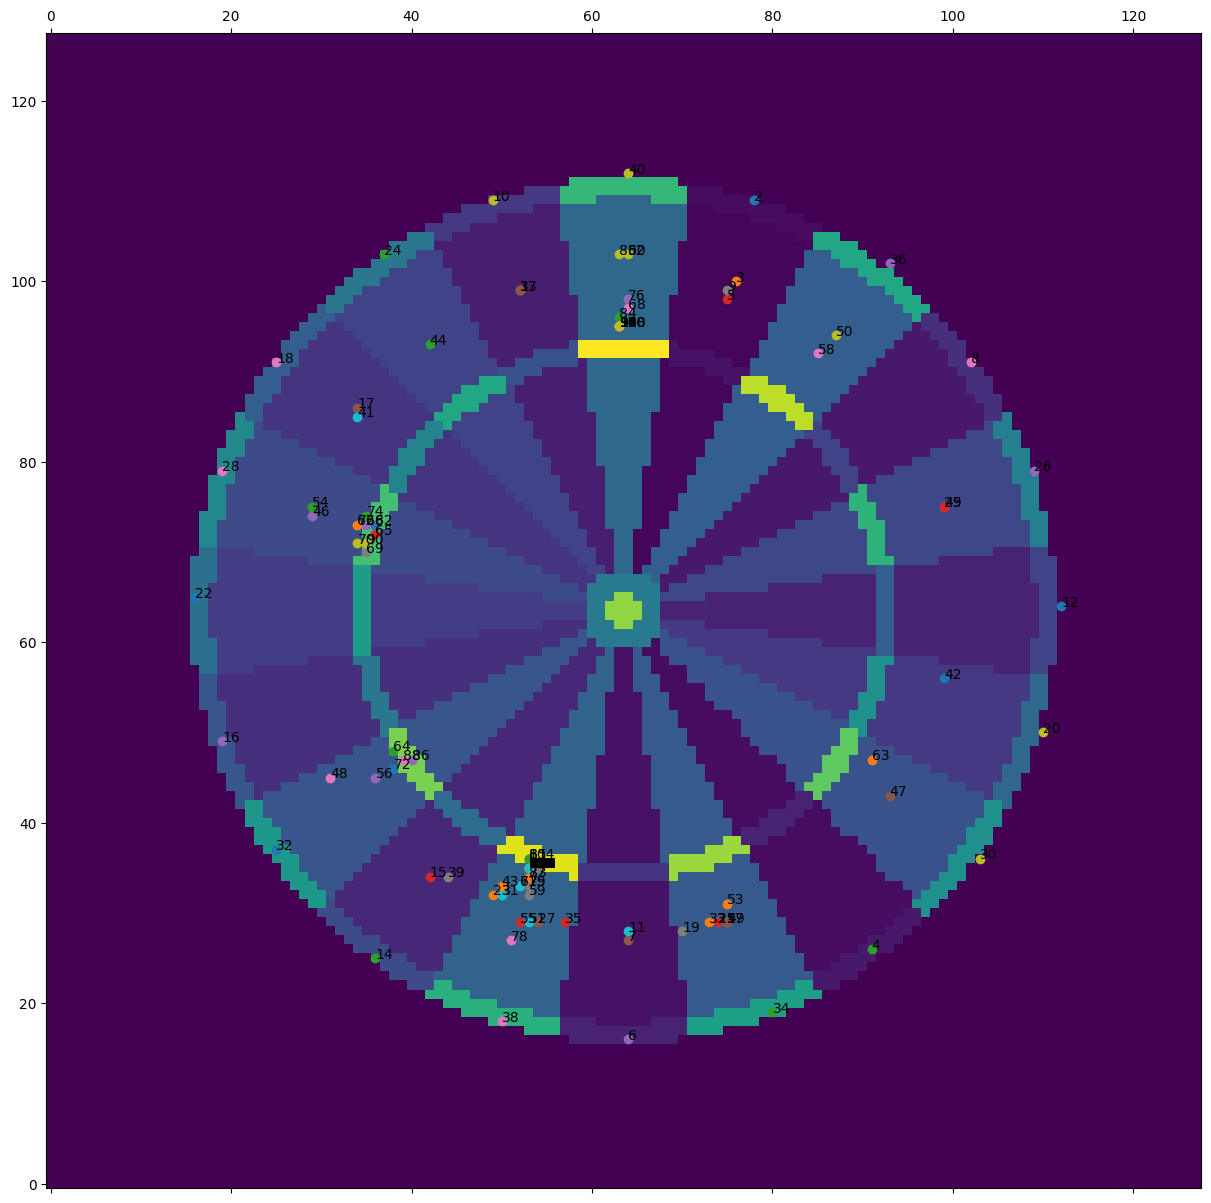

In [78]:
fig, ax = plt.subplots(figsize=(15, 15))
for s, point in policy.items():
    ax.scatter(*point[::-1])
    ax.annotate(s, [point[1], point[0]])
ax.matshow(board, origin='lower')

In [259]:
import pandas as pd
import os

In [260]:
#os.mkdir('inf-round_1-player/256pixel_12sigma')

In [261]:
#pd.DataFrame(points).to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/points.csv')

In [262]:
#pd.DataFrame(dict(policy)).T.to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/policy.csv')

In [263]:
#pd.DataFrame(values.items(), columns=['state', 'value']).set_index('state').to_csv(f'inf-round_1-player/{board_size}pixel_{sigma}sigma/values.csv')